# Predicting Credit Default Risk

**Course:** Python for Data Analytics by UNFC  

## Project Overview

This project analyzes historical loan application data and develops machine-learning models to predict whether a loan application will result in default.

The target variable is defined as:

- `target_default = 1` when `outcome_status` is `"Charged Off"`
- `target_default = 0` otherwise

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [ ]:
applications = pd.read_csv("creditrisk_applications_final.csv")
inquiries = pd.read_csv("creditrisk_inquiries_final.csv")

print("Applications dataset shape:", applications.shape)
print("Inquiries dataset shape:", inquiries.shape)

Applications dataset shape: (85000, 22)
Inquiries dataset shape: (45000, 8)


## 1. Initial Data Inspection

This section examines the structure, columns, data types, missing values, and duplicate records in both datasets before cleaning and analysis.

In [ ]:
print("Applications dataset preview:")
display(applications.head())

print("Inquiries dataset preview:")
display(inquiries.head())

Applications dataset preview:


,application_id,requested_amount_usd,repayment_term_text,interest_rate_text,monthly_installment_usd,last_payment_amount_usd,risk_grade_band,risk_grade_detail,employment_tenure_text,housing_status,annual_income_usd,income_verification_status,origination_month,outcome_status,loan_purpose,region_code,debt_to_income_ratio,credit_score_low,credit_score_high,open_credit_lines,public_records_count,revolving_utilization_text
0,41080563,18000.0,60 months,13.33,412.61,15325.62,C,C3,3 years,OWN,105000.0,Verified,Feb-2015,Fully Paid,debt_consolidation,AZ,6.78,670.0,674.0,7.0,0.0,89.5
1,76295652,1000.0,36 months,11.99,33.21,842.45,C,C1,1 year,RENT,28500.0,Not Verified,Apr-2016,Fully Paid,home_improvement,FL,11.54,690.0,694.0,3.0,1.0,13.3
2,60586596,21275.0,36 months,10.99,696.42,7380.80,B,B4,5 years,MORTGAGE,130000.0,Verified,Sep-2015,Fully Paid,debt_consolidation,PA,23.08,680.0,684.0,13.0,0.0,75.7
3,59310389,35000.0,60 months,16.99,869.66,32305.48,D,D3,10+ years,MORTGAGE,107000.0,Source Verified,Sep-2015,Fully Paid,credit_card,SC,16.3,710.0,714.0,10.0,0.0,76.5
4,44516103,17000.0,60 months,17.57,427.73,427.73,D,D4,8 years,RENT,55000.0,Source Verified,Apr-2015,Charged Off,credit_card,CA,31.27,680.0,684.0,8.0,0.0,62.5


Inquiries dataset preview:


,requested_amount_usd,application_date,request_title,screening_score,debt_to_income_text,region_code,employment_tenure_text,policy_code
0,1000.0,2007-05-26,Wedding Covered but No Honeymoon,693.0,10%,NM,4 years,0.0
1,1000.0,2007-05-26,Consolidating Debt,703.0,10%,MA,< 1 year,0.0
2,11000.0,2007-05-27,Want to consolidate my debt,715.0,10%,MD,1 year,0.0
3,6000.0,2007-05-27,waksman,698.0,38.64%,MA,< 1 year,0.0
4,1500.0,2007-05-27,mdrigo,509.0,9.43%,MD,< 1 year,0.0


In [ ]:
print("Applications dataset information:")
applications.info()

print("\nInquiries dataset information:")
inquiries.info()

Applications dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 85000 entries, 0 to 84999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   application_id              85000 non-null  int64  
 1   requested_amount_usd        85000 non-null  float64
 2   repayment_term_text         85000 non-null  str    
 3   interest_rate_text          85000 non-null  float64
 4   monthly_installment_usd     85000 non-null  float64
 5   last_payment_amount_usd     85000 non-null  float64
 6   risk_grade_band             85000 non-null  str    
 7   risk_grade_detail           85000 non-null  str    
 8   employment_tenure_text      76324 non-null  str    
 9   housing_status              85000 non-null  str    
 10  annual_income_usd           84320 non-null  float64
 11  income_verification_status  85000 non-null  str    
 12  origination_month           85000 non-null  str    
 13  outcome_

## 2. Data Quality Assessment

This section checks for missing values and duplicate records in both datasets. These checks help identify data-quality problems that must be addressed before exploratory analysis and machine-learning modeling.

In [ ]:
# Missing values in the applications dataset
applications_missing = pd.DataFrame({
    "Missing Count": applications.isnull().sum(),
    "Missing Percentage": (
        applications.isnull().sum() / len(applications) * 100
    ).round(2)
})

applications_missing = applications_missing[
    applications_missing["Missing Count"] > 0
].sort_values("Missing Count", ascending=False)

print("Missing values in applications dataset:")
display(applications_missing)

Missing values in applications dataset:


,Missing Count,Missing Percentage
employment_tenure_text,8676,10.21
revolving_utilization_text,892,1.05
debt_to_income_ratio,709,0.83
annual_income_usd,680,0.80


In [ ]:
# Missing values in the inquiries dataset
inquiries_missing = pd.DataFrame({
    "Missing Count": inquiries.isnull().sum(),
    "Missing Percentage": (
        inquiries.isnull().sum() / len(inquiries) * 100
    ).round(2)
})

inquiries_missing = inquiries_missing[
    inquiries_missing["Missing Count"] > 0
].sort_values("Missing Count", ascending=False)

print("Missing values in inquiries dataset:")
display(inquiries_missing)

Missing values in inquiries dataset:


,Missing Count,Missing Percentage
screening_score,4524,10.05
region_code,21,0.05
request_title,9,0.02
employment_tenure_text,2,0.00


In [ ]:
print("Duplicate rows in applications dataset:",
      applications.duplicated().sum())

print("Duplicate rows in inquiries dataset:",
      inquiries.duplicated().sum())

Duplicate rows in applications dataset: 0
Duplicate rows in inquiries dataset: 15


## 3. Creating the Target Variable

The prediction target is created from the `outcome_status` column:

- `target_default = 1` when the loan outcome is `Charged Off`
- `target_default = 0` otherwise

A charged-off loan represents a default.

In [ ]:
# Create the binary target variable
applications["target_default"] = np.where(
    applications["outcome_status"] == "Charged Off",
    1,
    0
)

print("Target variable created successfully.")

Target variable created successfully.


In [ ]:
# Check the original loan outcomes
outcome_summary = applications["outcome_status"].value_counts().to_frame("Count")

outcome_summary["Percentage"] = (
    applications["outcome_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(outcome_summary)

,Count,Percentage
outcome_status,,
Fully Paid,42500,50.0
Charged Off,42500,50.0


In [ ]:
# Check the target variable distribution
target_summary = applications["target_default"].value_counts().sort_index().to_frame("Count")

target_summary["Percentage"] = (
    applications["target_default"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_summary.index = ["No Default (0)", "Default (1)"]

display(target_summary)

,Count,Percentage
No Default (0),42500,50.0
Default (1),42500,50.0


## 4. Data Cleaning and Preparation

This section cleans inconsistent text fields, converts important variables into suitable numeric formats, removes duplicate inquiry records, and prepares the data for analysis and modeling.

In [ ]:
# Create working copies so the original datasets remain unchanged
applications_clean = applications.copy()
inquiries_clean = inquiries.copy()

# Remove duplicate rows from the inquiries dataset
inquiries_clean = inquiries_clean.drop_duplicates().reset_index(drop=True)

print("Applications rows:", len(applications_clean))
print("Inquiries rows after removing duplicates:", len(inquiries_clean))

Applications rows: 85000
Inquiries rows after removing duplicates: 44985


In [ ]:
# Convert repayment term from text such as "36 months" to numeric months
applications_clean["repayment_term_months"] = (
    applications_clean["repayment_term_text"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .astype(float)
)

# Review the conversion
display(
    applications_clean[
        ["repayment_term_text", "repayment_term_months"]
    ].drop_duplicates().sort_values("repayment_term_months")
)

,repayment_term_text,repayment_term_months
1,36 months,36.0
0,60 months,60.0


In [ ]:
# Function to convert employment tenure text into numeric years
def convert_employment_tenure(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    if value in ["< 1 year", "less than 1 year"]:
        return 0.5
    elif value in ["10+ years", "10 years or more"]:
        return 10.0
    elif value in ["n/a", "na", "none", "unknown"]:
        return np.nan
    else:
        extracted_number = pd.Series([value]).str.extract(r"(\d+)")[0].iloc[0]
        return float(extracted_number) if pd.notna(extracted_number) else np.nan


applications_clean["employment_tenure_years"] = (
    applications_clean["employment_tenure_text"]
    .apply(convert_employment_tenure)
)

inquiries_clean["employment_tenure_years"] = (
    inquiries_clean["employment_tenure_text"]
    .apply(convert_employment_tenure)
)

display(
    applications_clean[
        ["employment_tenure_text", "employment_tenure_years"]
    ].drop_duplicates().sort_values("employment_tenure_years")
)

,employment_tenure_text,employment_tenure_years
19,< 1 year,0.5
1,1 year,1.0
8,2 years,2.0
0,3 years,3.0
26,4 years,4.0
2,5 years,5.0
49,6 years,6.0
20,7 years,7.0
4,8 years,8.0
6,9 years,9.0


In [ ]:
# Clean debt-to-income ratio in the applications dataset
applications_clean["debt_to_income_numeric"] = pd.to_numeric(
    applications_clean["debt_to_income_ratio"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip(),
    errors="coerce"
)

# Clean revolving utilization
applications_clean["revolving_utilization_numeric"] = pd.to_numeric(
    applications_clean["revolving_utilization_text"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip(),
    errors="coerce"
)

# Clean debt-to-income field in the inquiries dataset
inquiries_clean["debt_to_income_numeric"] = pd.to_numeric(
    inquiries_clean["debt_to_income_text"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip(),
    errors="coerce"
)

print("Numeric cleaning completed.")

Numeric cleaning completed.


## 5. Validation of Cleaned Variables

After converting the text-based variables, the cleaned values are reviewed to confirm that the transformations were successful. The loan origination month is also converted into a date format so that year and month features can be used in later analysis.

In [ ]:
# Check the cleaned numeric columns
cleaning_check = applications_clean[
    [
        "repayment_term_months",
        "employment_tenure_years",
        "debt_to_income_numeric",
        "revolving_utilization_numeric"
    ]
].describe().T

display(cleaning_check)

,count,mean,std,min,25%,50%,75%,max
repayment_term_months,85000.0,43.278212,11.032051,36.0,36.0,36.00,60.00,60.0
employment_tenure_years,76324.0,5.941113,3.654222,0.5,2.0,6.00,10.00,10.0
debt_to_income_numeric,83955.0,19.682500,13.170892,0.0,12.8,18.99,25.91,999.0
revolving_utilization_numeric,84108.0,52.342891,24.293508,0.0,34.2,52.80,70.90,136.4


In [ ]:
# Convert origination month into a proper date
applications_clean["origination_date"] = pd.to_datetime(
    applications_clean["origination_month"],
    format="%b-%Y",
    errors="coerce"
)

# Create separate year and month features
applications_clean["origination_year"] = (
    applications_clean["origination_date"].dt.year
)

applications_clean["origination_month_number"] = (
    applications_clean["origination_date"].dt.month
)

display(
    applications_clean[
        [
            "origination_month",
            "origination_date",
            "origination_year",
            "origination_month_number"
        ]
    ].head()
)

,origination_month,origination_date,origination_year,origination_month_number
0,Feb-2015,2015-02-01,2015,2
1,Apr-2016,2016-04-01,2016,4
2,Sep-2015,2015-09-01,2015,9
3,Sep-2015,2015-09-01,2015,9
4,Apr-2015,2015-04-01,2015,4


In [ ]:
# Check missing values after numeric conversion
cleaned_missing_summary = applications_clean[
    [
        "repayment_term_months",
        "employment_tenure_years",
        "debt_to_income_numeric",
        "revolving_utilization_numeric",
        "annual_income_usd",
        "origination_date"
    ]
].isnull().sum().to_frame("Missing Count")

cleaned_missing_summary["Missing Percentage"] = (
    cleaned_missing_summary["Missing Count"]
    / len(applications_clean)
    * 100
).round(2)

display(cleaned_missing_summary)

,Missing Count,Missing Percentage
repayment_term_months,0,0.00
employment_tenure_years,8676,10.21
debt_to_income_numeric,1045,1.23
revolving_utilization_numeric,892,1.05
annual_income_usd,680,0.80
origination_date,0,0.00


In [ ]:
# Check for impossible or invalid numeric values
invalid_value_summary = pd.Series({
    "Requested amount <= 0":
        (applications_clean["requested_amount_usd"] <= 0).sum(),

    "Annual income <= 0":
        (applications_clean["annual_income_usd"] <= 0).sum(),

    "Interest rate <= 0":
        (applications_clean["interest_rate_text"] <= 0).sum(),

    "Debt-to-income < 0":
        (applications_clean["debt_to_income_numeric"] < 0).sum(),

    "Credit score low > credit score high":
        (
            applications_clean["credit_score_low"]
            > applications_clean["credit_score_high"]
        ).sum(),

    "Open credit lines < 0":
        (applications_clean["open_credit_lines"] < 0).sum(),

    "Public records < 0":
        (applications_clean["public_records_count"] < 0).sum()
})

display(invalid_value_summary.to_frame("Invalid Record Count"))

,Invalid Record Count
Requested amount <= 0,0
Annual income <= 0,24
Interest rate <= 0,0
Debt-to-income < 0,0
Credit score low > credit score high,0
Open credit lines < 0,0
Public records < 0,0


### Outlier Assessment and Treatment

Numeric variables were reviewed using descriptive statistics, histograms, and boxplots. Extreme values were not automatically deleted because unusually high loan amounts, income levels, debt-to-income ratios, and credit utilization may represent valid applicants rather than data-entry errors.

Impossible values, such as negative loan amounts, negative credit-line counts, or reversed credit-score ranges, were checked separately. Valid extreme observations were retained so the models could learn from the full range of historical credit-risk behaviour. Tree-based models are also relatively robust to extreme numeric values, while numeric variables used by Logistic Regression were standardized through the preprocessing pipeline.

## 6. Missing-Value Treatment

Missing numeric values are not removed immediately because deleting them could reduce the dataset unnecessarily. For modeling, numeric variables will be filled with the median and categorical variables will be filled with the most frequent category through a machine-learning preprocessing pipeline.

In [ ]:
# Review the missing values that remain after cleaning
columns_for_missing_review = [
    "employment_tenure_years",
    "debt_to_income_numeric",
    "revolving_utilization_numeric",
    "annual_income_usd",
    "origination_date"
]

missing_review = applications_clean[
    columns_for_missing_review
].isnull().sum().to_frame("Missing Count")

missing_review["Missing Percentage"] = (
    missing_review["Missing Count"]
    / len(applications_clean)
    * 100
).round(2)

display(missing_review)

,Missing Count,Missing Percentage
employment_tenure_years,8676,10.21
debt_to_income_numeric,1045,1.23
revolving_utilization_numeric,892,1.05
annual_income_usd,680,0.80
origination_date,0,0.00


## 7. Exploratory Data Analysis

This section examines the distribution of loan outcomes and identifies important patterns between borrower characteristics, loan attributes, and default risk.

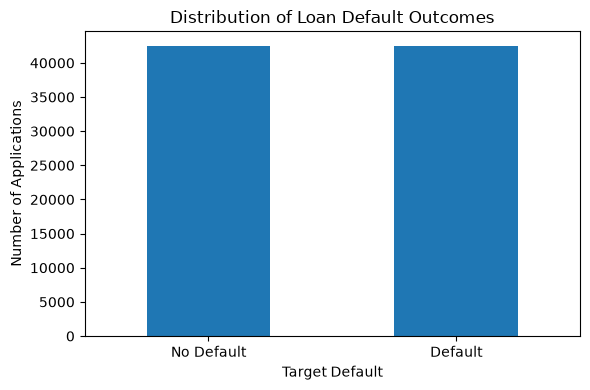

In [ ]:
# Target distribution
target_counts = applications_clean["target_default"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")

plt.title("Distribution of Loan Default Outcomes")
plt.xlabel("Target Default")
plt.ylabel("Number of Applications")
plt.xticks(
    ticks=[0, 1],
    labels=["No Default", "Default"],
    rotation=0
)

plt.tight_layout()
plt.show()

,Default Rate (%)
risk_grade_band,
A,19.797422
B,38.046200
C,53.510414
D,64.967851
E,73.625316
F,79.131704
G,79.936642


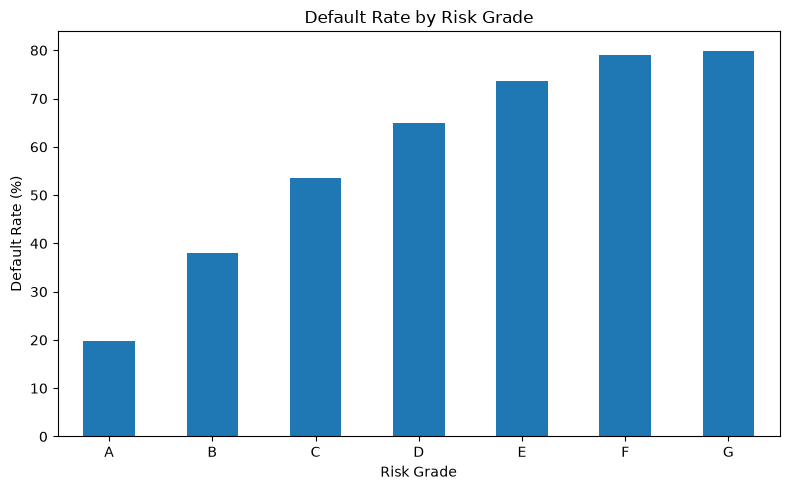

In [ ]:
# Default rate by risk grade
default_by_grade = (
    applications_clean
    .groupby("risk_grade_band")["target_default"]
    .mean()
    .mul(100)
    .sort_index()
)

display(default_by_grade.to_frame("Default Rate (%)"))

plt.figure(figsize=(8, 5))
default_by_grade.plot(kind="bar")

plt.title("Default Rate by Risk Grade")
plt.xlabel("Risk Grade")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

,Default Rate (%)
loan_purpose,
small_business,62.440191
moving,62.279294
moving,61.538462
major_purchase,58.695652
small_business,53.333333
medical,52.145923
debt_consolidation,52.002270
other,51.046114
debt_consolidation,50.420168


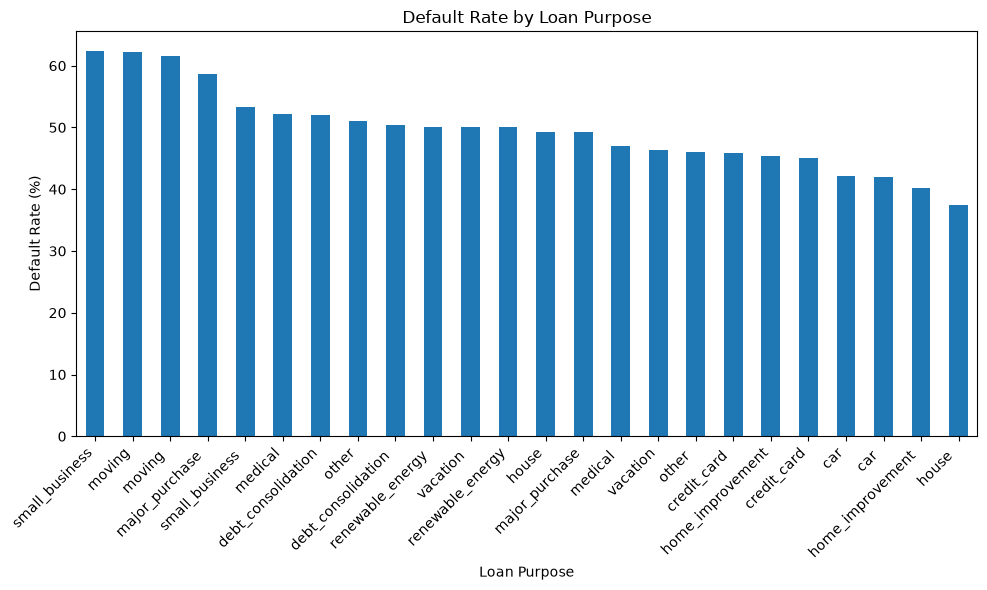

In [ ]:
# Default rate by loan purpose
default_by_purpose = (
    applications_clean
    .groupby("loan_purpose")["target_default"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(default_by_purpose.to_frame("Default Rate (%)"))

plt.figure(figsize=(10, 6))
default_by_purpose.plot(kind="bar")

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

,Default Rate (%)
housing_status,
ANY,100.000000
rent,55.176337
RENT,54.949346
OWN,50.779841
own,48.117155
mortgage,47.467726
MORTGAGE,45.175933


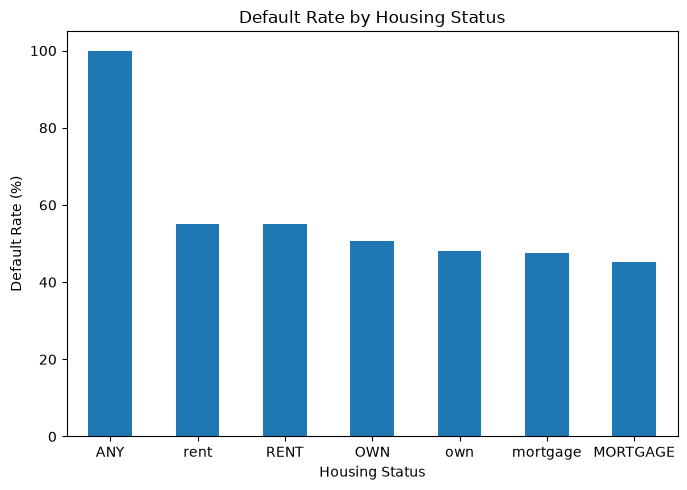

In [ ]:
# Default rate by housing status
default_by_housing = (
    applications_clean
    .groupby("housing_status")["target_default"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(default_by_housing.to_frame("Default Rate (%)"))

plt.figure(figsize=(7, 5))
default_by_housing.plot(kind="bar")

plt.title("Default Rate by Housing Status")
plt.xlabel("Housing Status")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Compare important numeric variables by loan outcome
numeric_comparison = applications_clean.groupby("target_default")[
    [
        "requested_amount_usd",
        "interest_rate_text",
        "annual_income_usd",
        "debt_to_income_numeric",
        "credit_score_low",
        "open_credit_lines",
        "public_records_count",
        "revolving_utilization_numeric"
    ]
].median().T

numeric_comparison.columns = ["No Default Median", "Default Median"]

display(numeric_comparison)

,No Default Median,Default Median
requested_amount_usd,12000.00,14400.00
interest_rate_text,11.53,14.65
annual_income_usd,65000.00,60000.00
debt_to_income_numeric,17.54,20.50
credit_score_low,690.00,680.00
open_credit_lines,11.00,11.00
public_records_count,0.00,0.00
revolving_utilization_numeric,50.60,54.70


<Figure size 800x500 with 0 Axes>

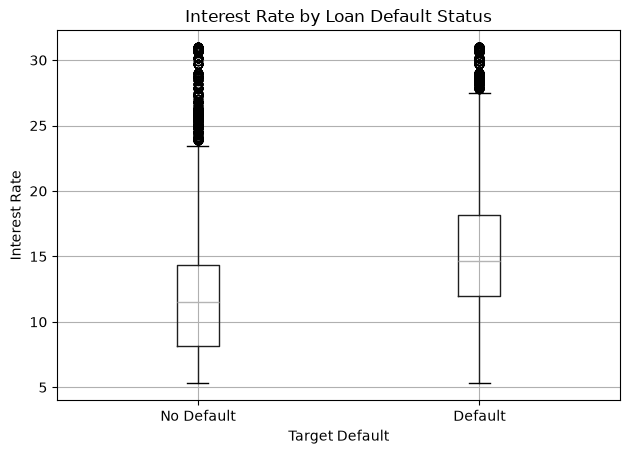

In [ ]:
# Interest-rate distribution by default status
plt.figure(figsize=(8, 5))

applications_clean.boxplot(
    column="interest_rate_text",
    by="target_default"
)

plt.title("Interest Rate by Loan Default Status")
plt.suptitle("")
plt.xlabel("Target Default")
plt.ylabel("Interest Rate")
plt.xticks(
    ticks=[1, 2],
    labels=["No Default", "Default"]
)

plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

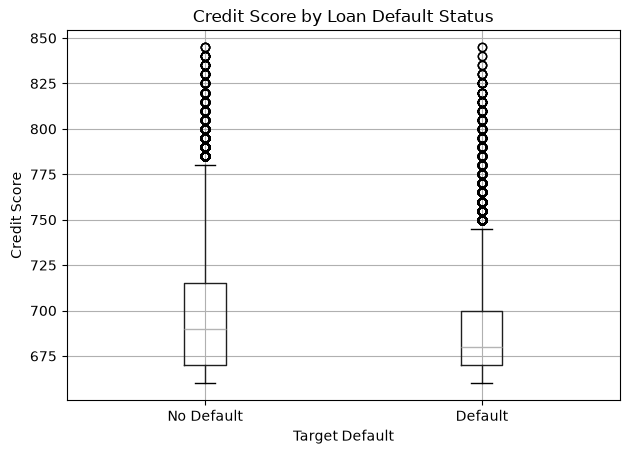

In [ ]:
# Credit-score distribution by default status
plt.figure(figsize=(8, 5))

applications_clean.boxplot(
    column="credit_score_low",
    by="target_default"
)

plt.title("Credit Score by Loan Default Status")
plt.suptitle("")
plt.xlabel("Target Default")
plt.ylabel("Credit Score")

plt.xticks(
    ticks=[1, 2],
    labels=["No Default", "Default"]
)

plt.tight_layout()
plt.show()

## 8. Correlation Analysis

This section examines relationships among important numeric variables. Correlation does not prove causation, but it can help identify variables that move together and may be useful for prediction.

In [ ]:
# Select numeric variables for correlation analysis
correlation_columns = [
    "requested_amount_usd",
    "repayment_term_months",
    "interest_rate_text",
    "monthly_installment_usd",
    "annual_income_usd",
    "employment_tenure_years",
    "debt_to_income_numeric",
    "credit_score_low",
    "credit_score_high",
    "open_credit_lines",
    "public_records_count",
    "revolving_utilization_numeric",
    "target_default"
]

correlation_matrix = applications_clean[
    correlation_columns
].corr()

display(correlation_matrix.round(2))

,requested_amount_usd,repayment_term_months,interest_rate_text,monthly_installment_usd,annual_income_usd,employment_tenure_years,debt_to_income_numeric,credit_score_low,credit_score_high,open_credit_lines,public_records_count,revolving_utilization_numeric,target_default
requested_amount_usd,1.00,0.40,0.16,0.95,0.27,0.09,0.02,0.11,0.11,0.18,-0.07,0.11,0.07
repayment_term_months,0.40,1.00,0.43,0.15,0.04,0.05,0.07,-0.01,-0.01,0.09,-0.02,0.06,0.23
interest_rate_text,0.16,0.43,1.00,0.17,-0.07,-0.02,0.15,-0.34,-0.34,0.00,0.05,0.16,0.34
monthly_installment_usd,0.95,0.15,0.17,1.00,0.26,0.08,0.02,0.07,0.07,0.16,-0.06,0.12,0.05
annual_income_usd,0.27,0.04,-0.07,0.26,1.00,0.07,-0.12,0.06,0.06,0.11,-0.00,0.04,-0.05
employment_tenure_years,0.09,0.05,-0.02,0.08,0.07,1.00,0.03,0.03,0.03,0.05,0.04,0.03,-0.02
debt_to_income_numeric,0.02,0.07,0.15,0.02,-0.12,0.03,1.00,-0.04,-0.04,0.19,-0.03,0.13,0.10
credit_score_low,0.11,-0.01,-0.34,0.07,0.06,0.03,-0.04,1.00,1.00,0.02,-0.19,-0.42,-0.17
credit_score_high,0.11,-0.01,-0.34,0.07,0.06,0.03,-0.04,1.00,1.00,0.02,-0.19,-0.42,-0.17
open_credit_lines,0.18,0.09,0.00,0.16,0.11,0.05,0.19,0.02,0.02,1.00,-0.02,-0.14,0.04


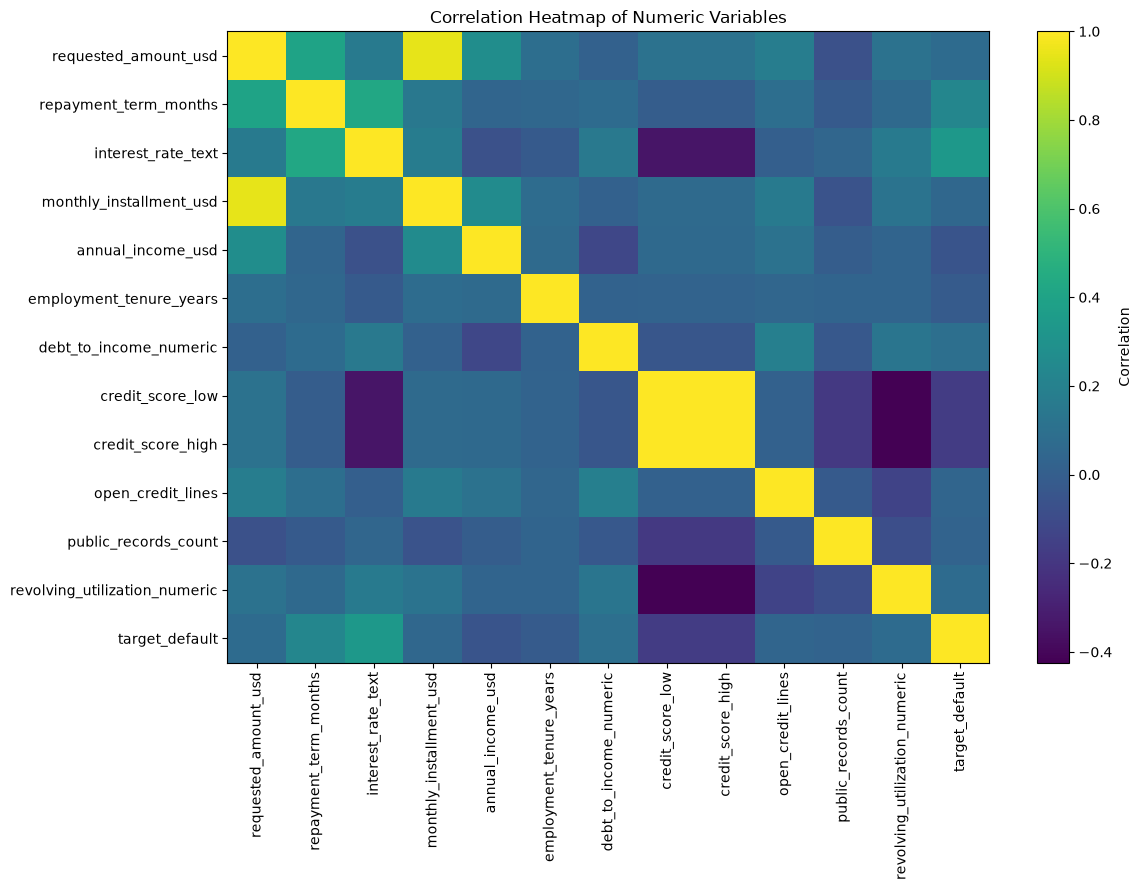

In [ ]:
plt.figure(figsize=(12, 9))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

## 9. Supplementary Inquiries Dataset Analysis

The inquiries dataset does not contain the final loan outcome or application identifier required for a direct row-level merge with the applications dataset. Therefore, it is analyzed separately to provide supplementary information about inquiry patterns and data quality.

In [ ]:
# Summary statistics for the inquiries dataset
inquiry_summary = inquiries_clean[
    [
        "requested_amount_usd",
        "screening_score",
        "debt_to_income_numeric",
        "employment_tenure_years",
        "policy_code"
    ]
].describe().T

display(inquiry_summary)

,count,mean,std,min,25%,50%,75%,max
requested_amount_usd,44985.0,9039.100737,6901.470645,500.0,3500.00,7000.00,14000.00,40000.0
screening_score,40472.0,574.057966,154.742359,0.0,513.00,609.00,670.00,828.0
debt_to_income_numeric,44985.0,2793.474357,30795.165646,-1.0,2.16,13.84,28.42,3626400.0
employment_tenure_years,44983.0,3.649634,3.420729,0.5,0.50,2.00,6.00,10.0
policy_code,44985.0,0.000000,0.000000,0.0,0.00,0.00,0.00,0.0


In [ ]:
# Convert inquiry application date
inquiries_clean["application_date"] = pd.to_datetime(
    inquiries_clean["application_date"],
    errors="coerce"
)

inquiries_clean["application_year"] = (
    inquiries_clean["application_date"].dt.year
)

inquiries_clean["application_month"] = (
    inquiries_clean["application_date"].dt.month
)

display(
    inquiries_clean[
        [
            "application_date",
            "application_year",
            "application_month"
        ]
    ].head()
)

,application_date,application_year,application_month
0,2007-05-26,2007,5
1,2007-05-26,2007,5
2,2007-05-27,2007,5
3,2007-05-27,2007,5
4,2007-05-27,2007,5


,Number of Inquiries
application_year,
2007,5272
2008,25590
2009,14123


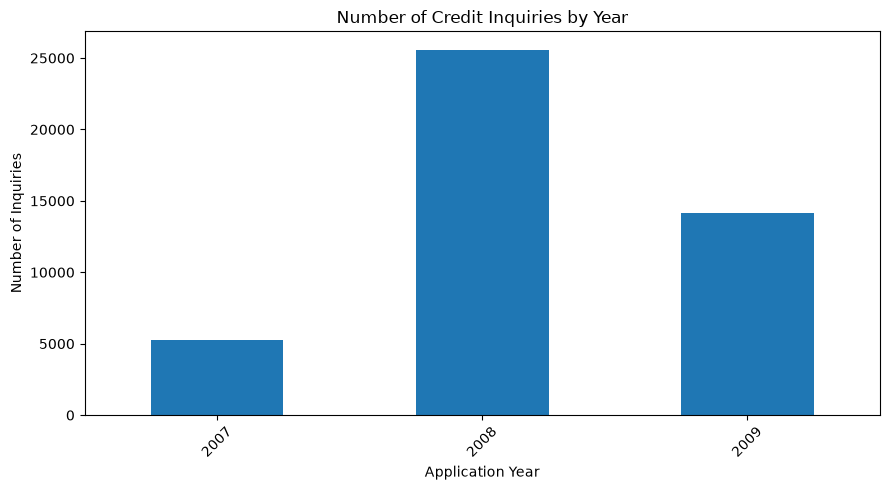

In [ ]:
# Number of inquiries by year
inquiries_by_year = (
    inquiries_clean["application_year"]
    .value_counts()
    .sort_index()
)

display(inquiries_by_year.to_frame("Number of Inquiries"))

plt.figure(figsize=(9, 5))
inquiries_by_year.plot(kind="bar")

plt.title("Number of Credit Inquiries by Year")
plt.xlabel("Application Year")
plt.ylabel("Number of Inquiries")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 10. Feature Selection and Target-Leakage Prevention

The model should use information that would be available when the loan application is reviewed.

The following variables are excluded:

- `application_id` because it is only an identifier.
- `outcome_status` because it directly defines the target variable.
- `last_payment_amount_usd` because it is recorded after the loan outcome and would create target leakage.
- Original text columns are excluded when cleaned numeric versions have already been created.
- Date columns are replaced with numeric year and month features.

Removing leakage variables helps produce a more realistic model that can be used before the final repayment outcome is known.

In [ ]:
# Select features for machine-learning modeling
model_features = [
    "requested_amount_usd",
    "repayment_term_months",
    "interest_rate_text",
    "monthly_installment_usd",
    "risk_grade_band",
    "risk_grade_detail",
    "employment_tenure_years",
    "housing_status",
    "annual_income_usd",
    "income_verification_status",
    "loan_purpose",
    "region_code",
    "debt_to_income_numeric",
    "credit_score_low",
    "credit_score_high",
    "open_credit_lines",
    "public_records_count",
    "revolving_utilization_numeric",
    "origination_year",
    "origination_month_number"
]

X = applications_clean[model_features].copy()
y = applications_clean["target_default"].copy()

print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

display(X.head())

Feature dataset shape: (85000, 20)
Target dataset shape: (85000,)


,requested_amount_usd,repayment_term_months,interest_rate_text,monthly_installment_usd,risk_grade_band,risk_grade_detail,employment_tenure_years,housing_status,annual_income_usd,income_verification_status,loan_purpose,region_code,debt_to_income_numeric,credit_score_low,credit_score_high,open_credit_lines,public_records_count,revolving_utilization_numeric,origination_year,origination_month_number
0,18000.0,60.0,13.33,412.61,C,C3,3.0,OWN,105000.0,Verified,debt_consolidation,AZ,6.78,670.0,674.0,7.0,0.0,89.5,2015,2
1,1000.0,36.0,11.99,33.21,C,C1,1.0,RENT,28500.0,Not Verified,home_improvement,FL,11.54,690.0,694.0,3.0,1.0,13.3,2016,4
2,21275.0,36.0,10.99,696.42,B,B4,5.0,MORTGAGE,130000.0,Verified,debt_consolidation,PA,23.08,680.0,684.0,13.0,0.0,75.7,2015,9
3,35000.0,60.0,16.99,869.66,D,D3,10.0,MORTGAGE,107000.0,Source Verified,credit_card,SC,16.30,710.0,714.0,10.0,0.0,76.5,2015,9
4,17000.0,60.0,17.57,427.73,D,D4,8.0,RENT,55000.0,Source Verified,credit_card,CA,31.27,680.0,684.0,8.0,0.0,62.5,2015,4


In [ ]:
# Identify numeric and categorical variables
numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numeric features:
['requested_amount_usd', 'repayment_term_months', 'interest_rate_text', 'monthly_installment_usd', 'employment_tenure_years', 'annual_income_usd', 'debt_to_income_numeric', 'credit_score_low', 'credit_score_high', 'open_credit_lines', 'public_records_count', 'revolving_utilization_numeric', 'origination_year', 'origination_month_number']

Categorical features:
['risk_grade_band', 'risk_grade_detail', 'housing_status', 'income_verification_status', 'loan_purpose', 'region_code']

Number of numeric features: 14
Number of categorical features: 6


## 11. Training and Testing Split

The dataset is divided into training and testing subsets.

- 80% of the records are used to train the models.
- 20% are reserved for final evaluation.
- Stratification is used to preserve the equal proportion of default and non-default cases in both subsets.
- A fixed random state is used to make the results reproducible.

In [ ]:
# Split the dataset into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).sort_index().to_frame("Proportion"))

print("Testing target distribution:")
display(y_test.value_counts(normalize=True).sort_index().to_frame("Proportion"))

Training feature shape: (68000, 20)
Testing feature shape: (17000, 20)

Training target distribution:


,Proportion
target_default,
0,0.5
1,0.5


Testing target distribution:


,Proportion
target_default,
0,0.5
1,0.5


## 12. Preprocessing Pipeline

Numeric and categorical variables require different preparation steps.

For numeric variables:

- Missing values are replaced with the median.
- Values are standardized for logistic regression.

For categorical variables:

- Missing values are replaced with the most frequent category.
- One-hot encoding converts categories into numeric indicator variables.
- Unknown categories in the testing data are ignored to prevent errors.

In [ ]:
# Numeric preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# Combine numeric and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 13. Model 1: Logistic Regression

Logistic Regression is used as the first classification model because it is simple, interpretable, and commonly used for binary outcomes such as default and non-default.

The model is combined with the preprocessing pipeline so that missing-value treatment, scaling, and categorical encoding are performed consistently.

In [ ]:
# Create the Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


In [ ]:
# Train the Logistic Regression model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
# Generate predictions
logistic_predictions = logistic_model.predict(X_test)

# Generate default probabilities
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


### Logistic Regression Evaluation

The model is evaluated using:

- Accuracy: overall proportion of correct predictions
- Precision: proportion of predicted defaults that were actual defaults
- Recall: proportion of actual defaults correctly detected
- F1-score: balance between precision and recall
- ROC-AUC: ability to separate default and non-default cases across thresholds

In credit-risk prediction, recall is especially important because failing to identify a borrower who later defaults may result in financial loss.

In [ ]:
# Calculate Logistic Regression evaluation metrics
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

logistic_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        logistic_accuracy,
        logistic_precision,
        logistic_recall,
        logistic_f1,
        logistic_roc_auc
    ]
})

logistic_results["Logistic Regression"] = (
    logistic_results["Logistic Regression"].round(4)
)

display(logistic_results)

,Metric,Logistic Regression
0,Accuracy,0.6644
1,Precision,0.6599
2,Recall,0.6784
3,F1-Score,0.6690
4,ROC-AUC,0.7238


In [ ]:
# Detailed classification report
print("Logistic Regression Classification Report:\n")

print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=[
            "No Default",
            "Default"
        ]
    )
)

Logistic Regression Classification Report:

              precision    recall  f1-score   support

  No Default       0.67      0.65      0.66      8500
     Default       0.66      0.68      0.67      8500

    accuracy                           0.66     17000
   macro avg       0.66      0.66      0.66     17000
weighted avg       0.66      0.66      0.66     17000



In [ ]:
# Logistic Regression confusion matrix
logistic_confusion_matrix = confusion_matrix(
    y_test,
    logistic_predictions
)

confusion_display = pd.DataFrame(
    logistic_confusion_matrix,
    index=[
        "Actual No Default",
        "Actual Default"
    ],
    columns=[
        "Predicted No Default",
        "Predicted Default"
    ]
)

display(confusion_display)

,Predicted No Default,Predicted Default
Actual No Default,5528,2972
Actual Default,2734,5766


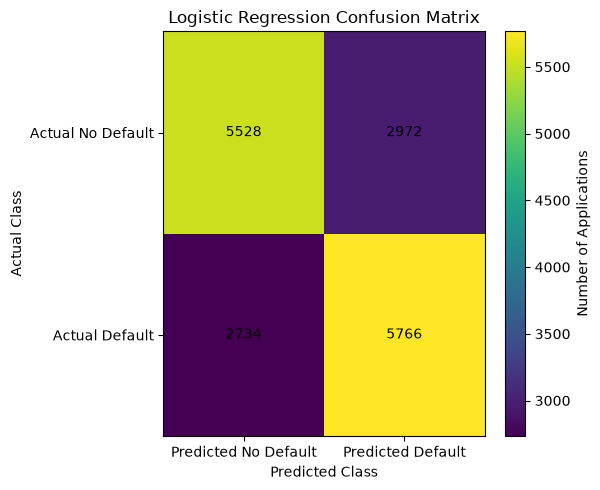

In [ ]:
# Display the Logistic Regression confusion matrix
plt.figure(figsize=(6, 5))

plt.imshow(
    logistic_confusion_matrix,
    aspect="auto"
)

plt.colorbar(label="Number of Applications")

plt.xticks(
    ticks=[0, 1],
    labels=[
        "Predicted No Default",
        "Predicted Default"
    ]
)

plt.yticks(
    ticks=[0, 1],
    labels=[
        "Actual No Default",
        "Actual Default"
    ]
)

for row in range(2):
    for column in range(2):
        plt.text(
            column,
            row,
            logistic_confusion_matrix[row, column],
            ha="center",
            va="center"
        )

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

## 14. Model 2: Random Forest

Random Forest is an ensemble machine-learning model that combines many decision trees. It can capture nonlinear relationships and interactions between borrower and loan characteristics.

Unlike Logistic Regression, Random Forest does not require numeric features to be standardized. However, the same preprocessing structure is retained so that missing values and categorical variables are handled consistently.

In [ ]:
# Create a separate preprocessing pipeline for Random Forest
numeric_transformer_rf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer_rf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor_rf = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer_rf, numeric_features),
        ("categorical", categorical_transformer_rf, categorical_features)
    ]
)

print("Random Forest preprocessing pipeline created.")

Random Forest preprocessing pipeline created.


In [ ]:
# Create the Random Forest pipeline
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_rf),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=15,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [ ]:
# Train the Random Forest model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
# Generate Random Forest predictions
random_forest_predictions = random_forest_model.predict(X_test)

# Generate default probabilities
random_forest_probabilities = (
    random_forest_model.predict_proba(X_test)[:, 1]
)

print("Random Forest predictions generated successfully.")

Random Forest predictions generated successfully.


### Random Forest Evaluation

The Random Forest model is evaluated using the same metrics as Logistic Regression so that the two models can be compared fairly.

In [ ]:
# Calculate Random Forest evaluation metrics
random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

random_forest_precision = precision_score(
    y_test,
    random_forest_predictions
)

random_forest_recall = recall_score(
    y_test,
    random_forest_predictions
)

random_forest_f1 = f1_score(
    y_test,
    random_forest_predictions
)

random_forest_roc_auc = roc_auc_score(
    y_test,
    random_forest_probabilities
)

random_forest_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Random Forest": [
        random_forest_accuracy,
        random_forest_precision,
        random_forest_recall,
        random_forest_f1,
        random_forest_roc_auc
    ]
})

random_forest_results["Random Forest"] = (
    random_forest_results["Random Forest"].round(4)
)

display(random_forest_results)

,Metric,Random Forest
0,Accuracy,0.6649
1,Precision,0.6568
2,Recall,0.6906
3,F1-Score,0.6733
4,ROC-AUC,0.7244


In [ ]:
print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test,
        random_forest_predictions,
        target_names=[
            "No Default",
            "Default"
        ]
    )
)

Random Forest Classification Report:

              precision    recall  f1-score   support

  No Default       0.67      0.64      0.66      8500
     Default       0.66      0.69      0.67      8500

    accuracy                           0.66     17000
   macro avg       0.67      0.66      0.66     17000
weighted avg       0.67      0.66      0.66     17000



In [ ]:
# Random Forest confusion matrix
random_forest_confusion_matrix = confusion_matrix(
    y_test,
    random_forest_predictions
)

random_forest_confusion_display = pd.DataFrame(
    random_forest_confusion_matrix,
    index=[
        "Actual No Default",
        "Actual Default"
    ],
    columns=[
        "Predicted No Default",
        "Predicted Default"
    ]
)

display(random_forest_confusion_display)

,Predicted No Default,Predicted Default
Actual No Default,5433,3067
Actual Default,2630,5870


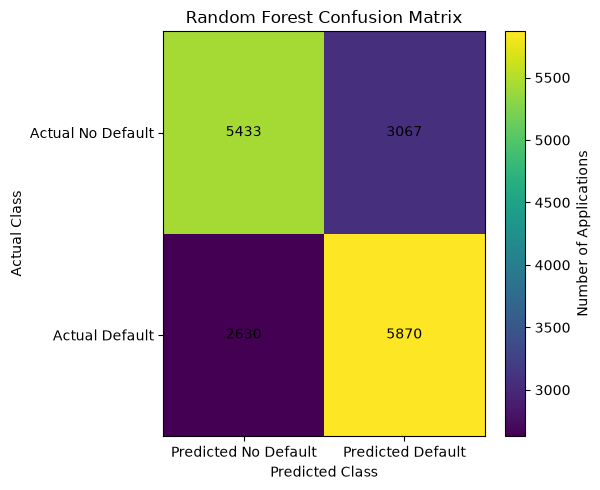

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(
    random_forest_confusion_matrix,
    aspect="auto"
)

plt.colorbar(label="Number of Applications")

plt.xticks(
    ticks=[0, 1],
    labels=[
        "Predicted No Default",
        "Predicted Default"
    ]
)

plt.yticks(
    ticks=[0, 1],
    labels=[
        "Actual No Default",
        "Actual Default"
    ]
)

for row in range(2):
    for column in range(2):
        plt.text(
            column,
            row,
            random_forest_confusion_matrix[row, column],
            ha="center",
            va="center"
        )

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

## 15. Model Comparison

The Logistic Regression and Random Forest models are compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

For credit-default prediction, recall is especially important because a false negative occurs when the model predicts that an applicant will not default, but the applicant actually defaults. This type of error may expose the lender to financial loss.

ROC-AUC is also important because it measures how well a model separates default and non-default applicants across different classification thresholds.

In [ ]:
# Create a model-comparison table
model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        logistic_accuracy,
        logistic_precision,
        logistic_recall,
        logistic_f1,
        logistic_roc_auc
    ],
    "Random Forest": [
        random_forest_accuracy,
        random_forest_precision,
        random_forest_recall,
        random_forest_f1,
        random_forest_roc_auc
    ]
})

model_comparison[
    ["Logistic Regression", "Random Forest"]
] = model_comparison[
    ["Logistic Regression", "Random Forest"]
].round(4)

display(model_comparison)

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.6644,0.6649
1,Precision,0.6599,0.6568
2,Recall,0.6784,0.6906
3,F1-Score,0.6690,0.6733
4,ROC-AUC,0.7238,0.7244


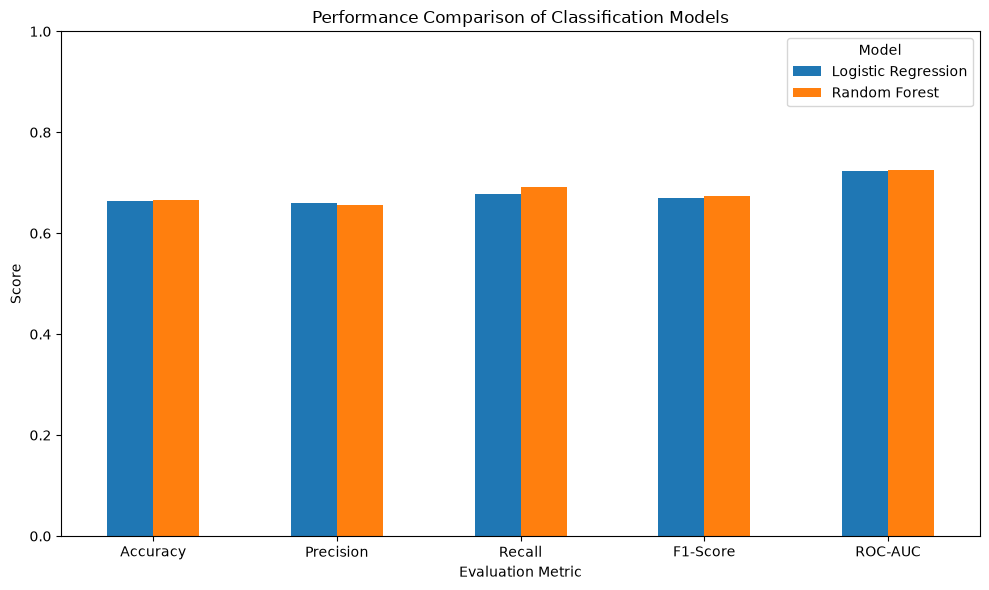

In [ ]:
# Compare the two models visually
comparison_plot = model_comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison of Classification Models")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

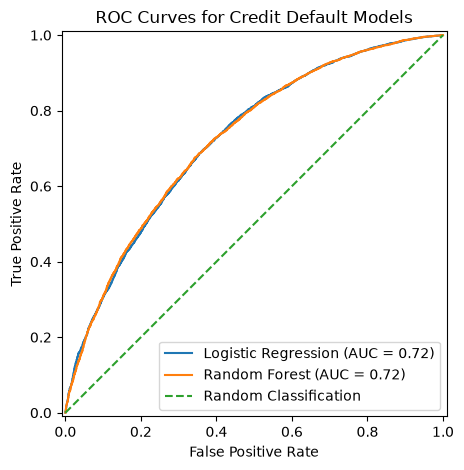

In [ ]:
# Plot ROC curves for both models
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    logistic_probabilities,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    random_forest_probabilities,
    name="Random Forest",
    ax=plt.gca()
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classification"
)

plt.title("ROC Curves for Credit Default Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Identify the model with the higher ROC-AUC score
if random_forest_roc_auc > logistic_roc_auc:
    recommended_model_name = "Random Forest"
    recommended_model = random_forest_model
    recommended_predictions = random_forest_predictions
    recommended_probabilities = random_forest_probabilities
else:
    recommended_model_name = "Logistic Regression"
    recommended_model = logistic_model
    recommended_predictions = logistic_predictions
    recommended_probabilities = logistic_probabilities

print(
    "Recommended model based on ROC-AUC:",
    recommended_model_name
)

Recommended model based on ROC-AUC: Random Forest


### Interpretation of Model Comparison

The preferred model should not be selected only by accuracy. The final recommendation should consider the model’s recall, F1-score, ROC-AUC, and the business cost of classification errors.

A model with stronger recall detects more actual defaults. A model with stronger precision produces fewer incorrect default warnings. ROC-AUC provides an overall measure of how effectively the model distinguishes between higher-risk and lower-risk applicants.

The recommended model will be selected after considering both statistical performance and its usefulness for credit-risk decision-making.

## 16. Feature Importance and Model Interpretation

Model interpretation helps explain which borrower and loan characteristics contribute most strongly to default-risk predictions.

For Random Forest, feature importance measures how much each transformed feature contributes to the model’s decisions.

For Logistic Regression, coefficient size and direction indicate how each feature is associated with the predicted probability of default.

In [ ]:
# Get transformed feature names
recommended_preprocessor = recommended_model.named_steps["preprocessor"]

feature_names = recommended_preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))

Number of transformed features: 189


In [ ]:
# Extract feature importance or coefficients
if recommended_model_name == "Random Forest":
    importance_values = (
        recommended_model
        .named_steps["classifier"]
        .feature_importances_
    )

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance_values
    })

    feature_importance = (
        feature_importance
        .sort_values("Importance", ascending=False)
        .head(20)
    )

else:
    coefficient_values = (
        recommended_model
        .named_steps["classifier"]
        .coef_[0]
    )

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficient_values
    })

    feature_importance["Absolute Importance"] = (
        feature_importance["Coefficient"].abs()
    )

    feature_importance = (
        feature_importance
        .sort_values("Absolute Importance", ascending=False)
        .head(20)
    )

display(feature_importance)

,Feature,Importance
2,numeric__interest_rate_text,0.175336
14,categorical__risk_grade_band_A,0.097147
1,numeric__repayment_term_months,0.080934
6,numeric__debt_to_income_numeric,0.048864
7,numeric__credit_score_low,0.040279
3,numeric__monthly_installment_usd,0.037942
0,numeric__requested_amount_usd,0.036175
15,categorical__risk_grade_band_B,0.035978
8,numeric__credit_score_high,0.034289
5,numeric__annual_income_usd,0.033758


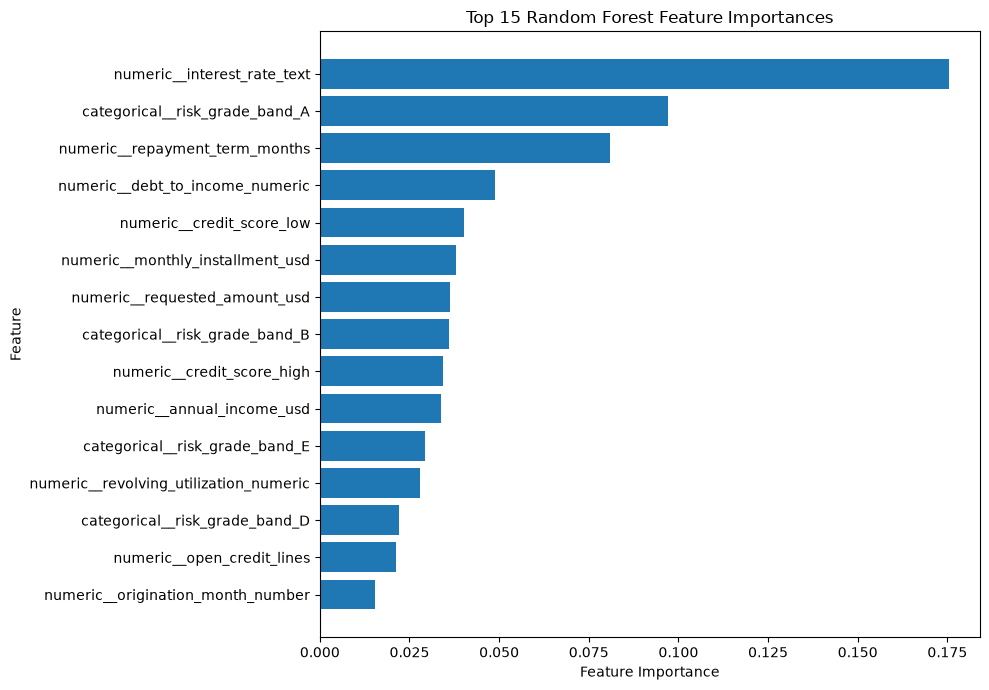

In [ ]:
# Plot the 15 most important predictors
if recommended_model_name == "Random Forest":
    top_features = feature_importance.head(15).sort_values(
        "Importance",
        ascending=True
    )

    plt.figure(figsize=(10, 7))
    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )

    plt.title("Top 15 Random Forest Feature Importances")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")

else:
    top_features = feature_importance.head(15).sort_values(
        "Absolute Importance",
        ascending=True
    )

    plt.figure(figsize=(10, 7))
    plt.barh(
        top_features["Feature"],
        top_features["Coefficient"]
    )

    plt.title("Top 15 Logistic Regression Coefficients")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Interpretation of Important Features

The feature-importance results identify the strongest variables used by the recommended model when distinguishing between default and non-default applications.

Higher importance does not prove that a variable causes default. It means that the variable contributes useful predictive information within this dataset.

The results should be interpreted together with the exploratory analysis, model metrics, business context, and possible relationships between correlated variables.

In [ ]:
# Compare default rates across major applicant groups
risk_group_summary = pd.concat(
    {
        "Risk Grade": (
            applications_clean
            .groupby("risk_grade_band")["target_default"]
            .mean()
            .mul(100)
            .sort_values(ascending=False)
            .head(5)
        ),
        "Loan Purpose": (
            applications_clean
            .groupby("loan_purpose")["target_default"]
            .mean()
            .mul(100)
            .sort_values(ascending=False)
            .head(5)
        ),
        "Housing Status": (
            applications_clean
            .groupby("housing_status")["target_default"]
            .mean()
            .mul(100)
            .sort_values(ascending=False)
            .head(5)
        )
    },
    names=["Category", "Group"]
).to_frame("Default Rate (%)")

display(risk_group_summary.round(2))

Default Rate (%)
Category       Group                            
Risk Grade     G                           79.94
               F                           79.13
               E                           73.63
               D                           64.97
               C                           53.51
Loan Purpose   small_business              62.44
               moving                      62.28
               moving                      61.54
               major_purchase              58.70
               small_business              53.33
Housing Status ANY                        100.00
               rent                        55.18
               RENT                        54.95
               OWN                         50.78
               own                         48.12

## 17. Classification Error Analysis

In credit-risk prediction, the two main types of classification error have different business consequences:

- A false positive occurs when the model predicts default, but the borrower does not default. This may cause the lender to reject a reliable customer.
- A false negative occurs when the model predicts no default, but the borrower actually defaults. This may expose the lender to financial loss.

False negatives are often more costly in credit-risk management, so recall for the default class is an important evaluation measure.

In [ ]:
# Calculate classification errors for the recommended model
recommended_confusion_matrix = confusion_matrix(
    y_test,
    recommended_predictions
)

true_negatives = recommended_confusion_matrix[0, 0]
false_positives = recommended_confusion_matrix[0, 1]
false_negatives = recommended_confusion_matrix[1, 0]
true_positives = recommended_confusion_matrix[1, 1]

error_analysis = pd.DataFrame({
    "Outcome": [
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives"
    ],
    "Number of Applications": [
        true_negatives,
        false_positives,
        false_negatives,
        true_positives
    ]
})

display(error_analysis)

print("Recommended model:", recommended_model_name)
print("False positive rate:", round(false_positives / (false_positives + true_negatives), 4))
print("False negative rate:", round(false_negatives / (false_negatives + true_positives), 4))

,Outcome,Number of Applications
0,True Negatives,5433
1,False Positives,3067
2,False Negatives,2630
3,True Positives,5870


Recommended model: Random Forest
False positive rate: 0.3608
False negative rate: 0.3094


## 18. Cross-Validation

Five-fold cross-validation is used to evaluate whether model performance remains consistent across different parts of the training data.

ROC-AUC is used as the evaluation metric because it measures how well each model separates default and non-default applications across different classification thresholds.

In [ ]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy created successfully.")

Cross-validation strategy created successfully.


In [ ]:


cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy created successfully.")

Cross-validation strategy created successfully.


In [ ]:
# Logistic Regression cross-validation
logistic_cv_scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1
)

print("Logistic Regression fold scores:")
print(logistic_cv_scores)

print(
    "Mean ROC-AUC:",
    round(logistic_cv_scores.mean(), 4)
)

print(
    "Standard deviation:",
    round(logistic_cv_scores.std(), 4)
)

Logistic Regression fold scores:
[0.72060372 0.72148629 0.72215195 0.72706497 0.71875593]
Mean ROC-AUC: 0.722
Standard deviation: 0.0028


In [ ]:
# Random Forest cross-validation
random_forest_cv_scores = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1
)

print("Random Forest fold scores:")
print(random_forest_cv_scores)

print(
    "Mean ROC-AUC:",
    round(random_forest_cv_scores.mean(), 4)
)

print(
    "Standard deviation:",
    round(random_forest_cv_scores.std(), 4)
)

Random Forest fold scores:
[0.72048002 0.72283929 0.72451263 0.72995521 0.72238655]
Mean ROC-AUC: 0.724
Standard deviation: 0.0032


In [ ]:
cross_validation_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Mean ROC-AUC": [
        logistic_cv_scores.mean(),
        random_forest_cv_scores.mean()
    ],
    "Standard Deviation": [
        logistic_cv_scores.std(),
        random_forest_cv_scores.std()
    ],
    "Minimum ROC-AUC": [
        logistic_cv_scores.min(),
        random_forest_cv_scores.min()
    ],
    "Maximum ROC-AUC": [
        logistic_cv_scores.max(),
        random_forest_cv_scores.max()
    ]
})

cross_validation_results.iloc[:, 1:] = (
    cross_validation_results.iloc[:, 1:].round(4)
)

display(cross_validation_results)

,Model,Mean ROC-AUC,Standard Deviation,Minimum ROC-AUC,Maximum ROC-AUC
0,Logistic Regression,0.722,0.0028,0.7188,0.7271
1,Random Forest,0.724,0.0032,0.7205,0.7300


In [ ]:
fold_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Logistic Regression": logistic_cv_scores,
    "Random Forest": random_forest_cv_scores
})

fold_results[
    ["Logistic Regression", "Random Forest"]
] = fold_results[
    ["Logistic Regression", "Random Forest"]
].round(4)

display(fold_results)

,Fold,Logistic Regression,Random Forest
0,1,0.7206,0.7205
1,2,0.7215,0.7228
2,3,0.7222,0.7245
3,4,0.7271,0.7300
4,5,0.7188,0.7224


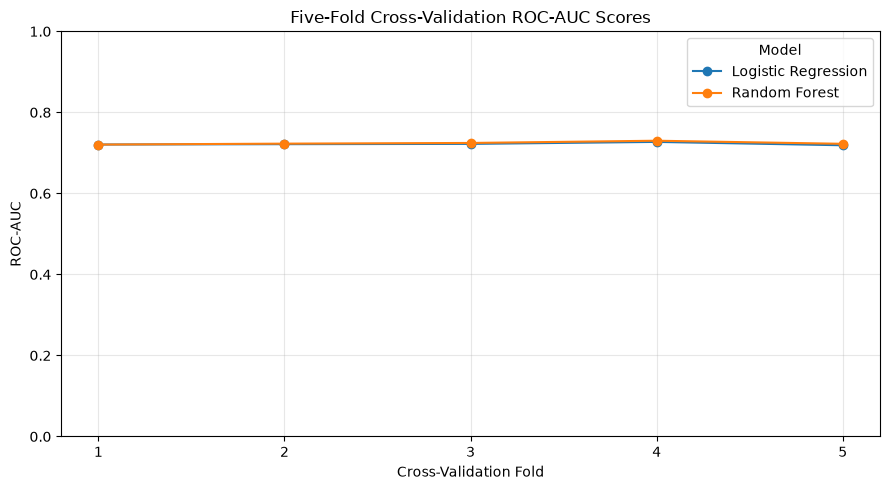

In [ ]:
cv_plot_data = fold_results.set_index("Fold")

cv_plot_data.plot(
    kind="line",
    marker="o",
    figsize=(9, 5)
)

plt.title("Five-Fold Cross-Validation ROC-AUC Scores")
plt.xlabel("Cross-Validation Fold")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.xticks([1, 2, 3, 4, 5])
plt.legend(title="Model")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Cross-Validation Interpretation

A higher mean ROC-AUC indicates stronger overall ability to distinguish between default and non-default applications.

A smaller standard deviation indicates that model performance is more consistent across the five validation folds.

### Overfitting and Underfitting Assessment

Training and validation performance were reviewed through cross-validation. The relatively consistent ROC-AUC scores across the five folds suggest that model performance was stable and that severe overfitting was not observed.

The tuned Random Forest produced only a modest improvement over the original Random Forest. This indicates that additional model complexity did not create an unrealistically large performance gain. At the same time, ROC-AUC remained below perfect classification, showing that the models do not fully capture every factor related to default risk. This is expected in real-world credit data and may reflect remaining noise, unobserved variables, and some underfitting.

## 19. Random Forest Hyperparameter Tuning

Hyperparameter tuning is used to test different Random Forest settings and identify a stronger model configuration.

Randomized Search is used because it tests several combinations efficiently without evaluating every possible combination.

ROC-AUC is used as the scoring metric because it measures how well the model separates default and non-default applications.

In [ ]:
# Define the Random Forest parameter options
random_forest_parameter_grid = {
    "classifier__n_estimators": [
        150,
        200,
        300,
        400
    ],
    "classifier__max_depth": [
        10,
        15,
        20,
        25,
        None
    ],
    "classifier__min_samples_split": [
        2,
        5,
        10,
        15
    ],
    "classifier__min_samples_leaf": [
        1,
        2,
        5,
        10
    ],
    "classifier__max_features": [
        "sqrt",
        "log2"
    ],
    "classifier__class_weight": [
        "balanced",
        None
    ]
}

print("Random Forest parameter grid created successfully.")

Random Forest parameter grid created successfully.


In [ ]:
# Create the cross-validation strategy for tuning
tuning_cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print("Tuning cross-validation strategy created successfully.")

Tuning cross-validation strategy created successfully.


In [ ]:
# Create the randomized hyperparameter search
random_search = RandomizedSearchCV(
    estimator=random_forest_model,
    param_distributions=random_forest_parameter_grid,
    n_iter=12,
    scoring="roc_auc",
    cv=tuning_cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Randomized Search created successfully.")

Randomized Search created successfully.


In [ ]:
# Run the hyperparameter search
random_search.fit(X_train, y_train)

print("Hyperparameter tuning completed.")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Hyperparameter tuning completed.


In [ ]:
# Display the best Random Forest settings
print("Best parameters:")
print(random_search.best_params_)

print(
    "\nBest cross-validation ROC-AUC:",
    round(random_search.best_score_, 4)
)

Best parameters:
{'classifier__n_estimators': 300, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': 25, 'classifier__class_weight': 'balanced'}

Best cross-validation ROC-AUC: 0.724


In [ ]:
# Store the best tuned Random Forest model
tuned_random_forest_model = random_search.best_estimator_

print("Best tuned Random Forest model saved successfully.")

Best tuned Random Forest model saved successfully.


In [ ]:
# Generate predictions from the tuned Random Forest
tuned_rf_predictions = tuned_random_forest_model.predict(
    X_test
)

tuned_rf_probabilities = (
    tuned_random_forest_model
    .predict_proba(X_test)[:, 1]
)

print("Tuned Random Forest predictions generated successfully.")

Tuned Random Forest predictions generated successfully.


In [ ]:
# Calculate evaluation metrics for the tuned Random Forest
tuned_rf_accuracy = accuracy_score(
    y_test,
    tuned_rf_predictions
)

tuned_rf_precision = precision_score(
    y_test,
    tuned_rf_predictions
)

tuned_rf_recall = recall_score(
    y_test,
    tuned_rf_predictions
)

tuned_rf_f1 = f1_score(
    y_test,
    tuned_rf_predictions
)

tuned_rf_roc_auc = roc_auc_score(
    y_test,
    tuned_rf_probabilities
)

tuned_rf_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Tuned Random Forest": [
        tuned_rf_accuracy,
        tuned_rf_precision,
        tuned_rf_recall,
        tuned_rf_f1,
        tuned_rf_roc_auc
    ]
})

tuned_rf_results["Tuned Random Forest"] = (
    tuned_rf_results["Tuned Random Forest"]
    .round(4)
)

display(tuned_rf_results)

,Metric,Tuned Random Forest
0,Accuracy,0.6660
1,Precision,0.6581
2,Recall,0.6911
3,F1-Score,0.6742
4,ROC-AUC,0.7251


In [ ]:
print("Tuned Random Forest Classification Report:\n")

print(
    classification_report(
        y_test,
        tuned_rf_predictions,
        target_names=[
            "No Default",
            "Default"
        ]
    )
)

Tuned Random Forest Classification Report:

              precision    recall  f1-score   support

  No Default       0.67      0.64      0.66      8500
     Default       0.66      0.69      0.67      8500

    accuracy                           0.67     17000
   macro avg       0.67      0.67      0.67     17000
weighted avg       0.67      0.67      0.67     17000



In [ ]:
# Create the tuned Random Forest confusion matrix
tuned_rf_confusion_matrix = confusion_matrix(
    y_test,
    tuned_rf_predictions
)

tuned_rf_confusion_display = pd.DataFrame(
    tuned_rf_confusion_matrix,
    index=[
        "Actual No Default",
        "Actual Default"
    ],
    columns=[
        "Predicted No Default",
        "Predicted Default"
    ]
)

display(tuned_rf_confusion_display)

,Predicted No Default,Predicted Default
Actual No Default,5448,3052
Actual Default,2626,5874


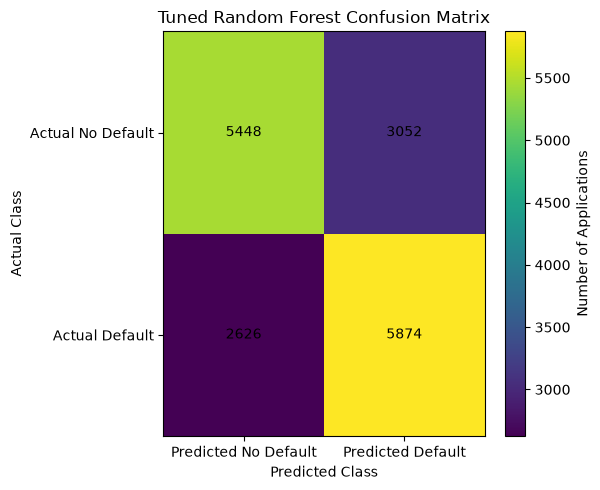

In [ ]:
# Plot the tuned Random Forest confusion matrix
plt.figure(figsize=(6, 5))

plt.imshow(
    tuned_rf_confusion_matrix,
    aspect="auto"
)

plt.colorbar(label="Number of Applications")

plt.xticks(
    ticks=[0, 1],
    labels=[
        "Predicted No Default",
        "Predicted Default"
    ]
)

plt.yticks(
    ticks=[0, 1],
    labels=[
        "Actual No Default",
        "Actual Default"
    ]
)

for row in range(2):
    for column in range(2):
        plt.text(
            column,
            row,
            tuned_rf_confusion_matrix[row, column],
            ha="center",
            va="center"
        )

plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

### Hyperparameter Tuning Interpretation

The tuned Random Forest model was selected using the highest cross-validation ROC-AUC score from the tested parameter combinations.

Its test-set performance should be compared with the original Random Forest and Logistic Regression models to determine whether tuning produced a meaningful improvement.

## 20. Final Model Comparison

The Logistic Regression, original Random Forest, and tuned Random Forest models are compared using the same testing dataset.

The comparison includes Accuracy, Precision, Recall, F1-score, and ROC-AUC.

The final model should be selected by considering both statistical performance and the business cost of classification errors.

In [ ]:
# Create the final model-comparison table
final_model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        logistic_accuracy,
        logistic_precision,
        logistic_recall,
        logistic_f1,
        logistic_roc_auc
    ],
    "Original Random Forest": [
        random_forest_accuracy,
        random_forest_precision,
        random_forest_recall,
        random_forest_f1,
        random_forest_roc_auc
    ],
    "Tuned Random Forest": [
        tuned_rf_accuracy,
        tuned_rf_precision,
        tuned_rf_recall,
        tuned_rf_f1,
        tuned_rf_roc_auc
    ]
})

final_model_comparison.iloc[:, 1:] = (
    final_model_comparison.iloc[:, 1:].round(4)
)

display(final_model_comparison)

,Metric,Logistic Regression,Original Random Forest,Tuned Random Forest
0,Accuracy,0.6644,0.6649,0.6660
1,Precision,0.6599,0.6568,0.6581
2,Recall,0.6784,0.6906,0.6911
3,F1-Score,0.6690,0.6733,0.6742
4,ROC-AUC,0.7238,0.7244,0.7251


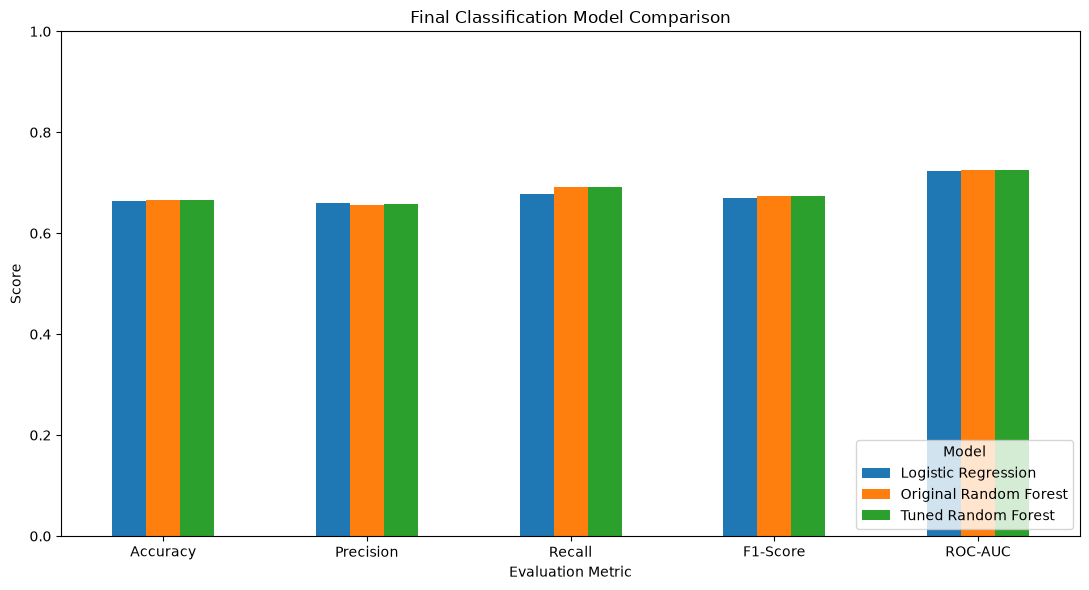

In [ ]:
# Plot the final model comparison
final_comparison_plot = final_model_comparison.set_index("Metric")

final_comparison_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Final Classification Model Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model", loc="lower right")

plt.tight_layout()
plt.show()

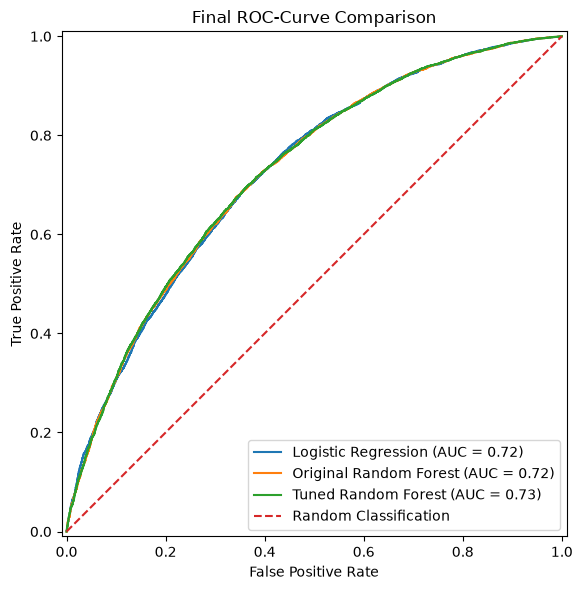

In [ ]:
# Plot ROC curves for all three models
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    logistic_probabilities,
    name="Logistic Regression",
    ax=plt.gca()
)

RocCurveDisplay.from_predictions(
    y_test,
    random_forest_probabilities,
    name="Original Random Forest",
    ax=plt.gca()
)

RocCurveDisplay.from_predictions(
    y_test,
    tuned_rf_probabilities,
    name="Tuned Random Forest",
    ax=plt.gca()
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classification"
)

plt.title("Final ROC-Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Select the final recommended model using ROC-AUC
final_model_scores = {
    "Logistic Regression": logistic_roc_auc,
    "Original Random Forest": random_forest_roc_auc,
    "Tuned Random Forest": tuned_rf_roc_auc
}

final_model_name = max(
    final_model_scores,
    key=final_model_scores.get
)

if final_model_name == "Logistic Regression":
    final_model = logistic_model
    final_predictions = logistic_predictions
    final_probabilities = logistic_probabilities

elif final_model_name == "Original Random Forest":
    final_model = random_forest_model
    final_predictions = random_forest_predictions
    final_probabilities = random_forest_probabilities

else:
    final_model = tuned_random_forest_model
    final_predictions = tuned_rf_predictions
    final_probabilities = tuned_rf_probabilities

print("Final recommended model:", final_model_name)
print(
    "Final model ROC-AUC:",
    round(final_model_scores[final_model_name], 4)
)

Final recommended model: Tuned Random Forest
Final model ROC-AUC: 0.7251


In [ ]:
# Create the final confusion matrix
final_confusion_matrix = confusion_matrix(
    y_test,
    final_predictions
)

final_true_negatives = final_confusion_matrix[0, 0]
final_false_positives = final_confusion_matrix[0, 1]
final_false_negatives = final_confusion_matrix[1, 0]
final_true_positives = final_confusion_matrix[1, 1]

final_error_analysis = pd.DataFrame({
    "Classification Result": [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ],
    "Number of Applications": [
        final_true_negatives,
        final_false_positives,
        final_false_negatives,
        final_true_positives
    ]
})

display(final_error_analysis)

,Classification Result,Number of Applications
0,True Negative,5448
1,False Positive,3052
2,False Negative,2626
3,True Positive,5874


In [ ]:
# Calculate the final false-positive and false-negative rates
final_false_negative_rate = (
    final_false_negatives /
    (final_false_negatives + final_true_positives)
)

final_false_positive_rate = (
    final_false_positives /
    (final_false_positives + final_true_negatives)
)

print(
    "False-negative rate:",
    round(final_false_negative_rate, 4)
)

print(
    "False-positive rate:",
    round(final_false_positive_rate, 4)
)

False-negative rate: 0.3089
False-positive rate: 0.3591


### Final Model Selection Interpretation

The final recommended model is selected primarily using ROC-AUC, while also considering recall, precision, F1-score, and classification errors.

Recall is especially important in credit-risk prediction because a false negative means that the model predicts no default for an applicant who later defaults.

The final model should therefore provide a suitable balance between identifying risky applicants and avoiding unnecessary rejection of reliable borrowers.

## 21. Business Insights

The analysis provides several practical insights for credit-risk decision-making.

1. Default risk is not the same across all applicants. It varies across risk grades, loan purposes, housing categories, and borrower credit characteristics.

2. Risk grade, interest rate, credit score, debt-to-income ratio, revolving-credit utilization, annual income, and other highly ranked model features provide useful information for identifying higher-risk applicants.

3. Applicants with weaker credit characteristics or less favourable affordability measures may require additional review before approval.

4. The model can support lenders by estimating the probability of default and ranking applications from lower risk to higher risk.

5. False negatives are especially important because they represent applicants predicted as non-default who later default. These errors may lead to financial loss.

6. False positives also have a business cost because reliable applicants may be rejected or offered less favourable terms.

7. The model should support credit analysts and underwriting staff rather than completely replace human judgment.

8. The findings show predictive associations, but they do not prove that any individual characteristic directly causes default.

In [ ]:
# Display the highest default-rate groups
highest_risk_groups = pd.concat(
    {
        "Risk Grade": (
            applications_clean
            .groupby("risk_grade_band")["target_default"]
            .mean()
            .mul(100)
            .sort_values(ascending=False)
            .head(5)
        ),
        "Loan Purpose": (
            applications_clean
            .groupby("loan_purpose")["target_default"]
            .mean()
            .mul(100)
            .sort_values(ascending=False)
            .head(5)
        ),
        "Housing Status": (
            applications_clean
            .groupby("housing_status")["target_default"]
            .mean()
            .mul(100)
            .sort_values(ascending=False)
            .head(5)
        )
    },
    names=["Category", "Group"]
).to_frame("Default Rate (%)")

display(highest_risk_groups.round(2))

Default Rate (%)
Category       Group                            
Risk Grade     G                           79.94
               F                           79.13
               E                           73.63
               D                           64.97
               C                           53.51
Loan Purpose   small_business              62.44
               moving                      62.28
               moving                      61.54
               major_purchase              58.70
               small_business              53.33
Housing Status ANY                        100.00
               rent                        55.18
               RENT                        54.95
               OWN                         50.78
               own                         48.12

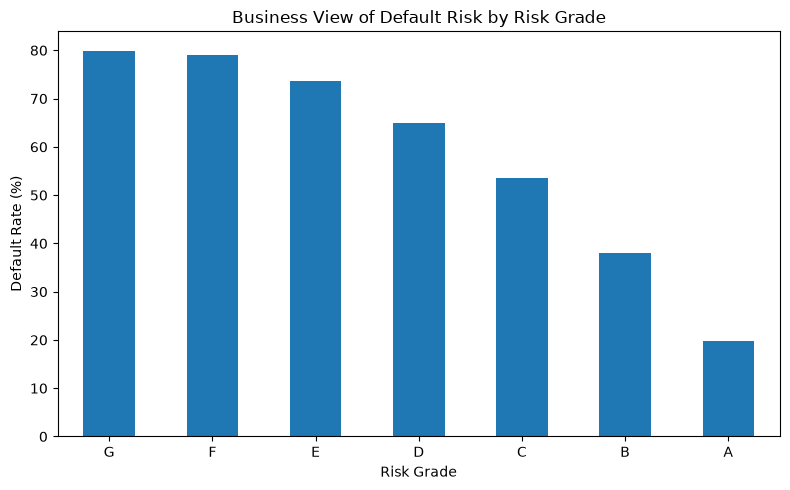

In [ ]:
risk_grade_business_summary = (
    applications_clean
    .groupby("risk_grade_band")["target_default"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

risk_grade_business_summary.plot(
    kind="bar"
)

plt.title("Business View of Default Risk by Risk Grade")
plt.xlabel("Risk Grade")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Business Interpretation

The highest-risk groups should not be automatically rejected. Instead, they may be prioritized for additional income verification, affordability checks, documentation review, or manual underwriting.

The model is most useful as a decision-support tool that helps credit teams focus their attention on applications with a higher estimated probability of default.

## 22. Business Recommendations

Based on the analysis and model results, the following actions are recommended:

1. Use the final recommended model as an initial credit-risk screening tool.

2. Show credit analysts both the predicted class and the estimated probability of default.

3. Send higher-risk applications for additional manual review instead of making fully automatic decisions.

4. Pay closer attention to important factors such as risk grade, credit score, interest rate, debt-to-income ratio, revolving utilization, and annual income.

5. Strengthen income and employment verification when an application has weaker affordability indicators.

6. Select the final decision threshold according to the financial cost of false negatives and false positives.

7. Monitor recall carefully because missed defaults may lead to direct financial loss.

8. Do not reject applicants only because of one characteristic or one model prediction.

9. Review model fairness before using it in real lending decisions.

10. Retrain and monitor the model regularly because applicant behaviour and economic conditions can change over time.

11. Improve the quality and completeness of borrower information, especially for fields with missing values.

12. Use the model as a support tool for credit analysts, not as a complete replacement for human judgment.

### Recommended Operational Use

A practical lending workflow could use the model in the following way:

- Low-risk applications may continue through the normal review process.
- Medium-risk applications may require additional document checks.
- High-risk applications may be sent for detailed manual underwriting.
- Final approval or rejection should remain subject to lending policy, legal requirements, fairness review, and professional judgment.

In [ ]:
# Create estimated risk categories from final model probabilities
risk_category = pd.cut(
    final_probabilities,
    bins=[0.0, 0.35, 0.65, 1.0],
    labels=[
        "Lower Estimated Risk",
        "Moderate Estimated Risk",
        "Higher Estimated Risk"
    ],
    include_lowest=True
)

risk_category_summary = pd.DataFrame({
    "Risk Category": risk_category,
    "Actual Default": y_test.reset_index(drop=True)
})

risk_category_results = (
    risk_category_summary
    .groupby("Risk Category", observed=False)
    .agg(
        Number_of_Applications=("Actual Default", "size"),
        Actual_Default_Rate=("Actual Default", "mean")
    )
)

risk_category_results["Actual_Default_Rate"] = (
    risk_category_results["Actual_Default_Rate"]
    .mul(100)
    .round(2)
)

display(risk_category_results)

,Number_of_Applications,Actual_Default_Rate
Risk Category,,
Lower Estimated Risk,3622,21.23
Moderate Estimated Risk,9611,50.91
Higher Estimated Risk,3767,75.34


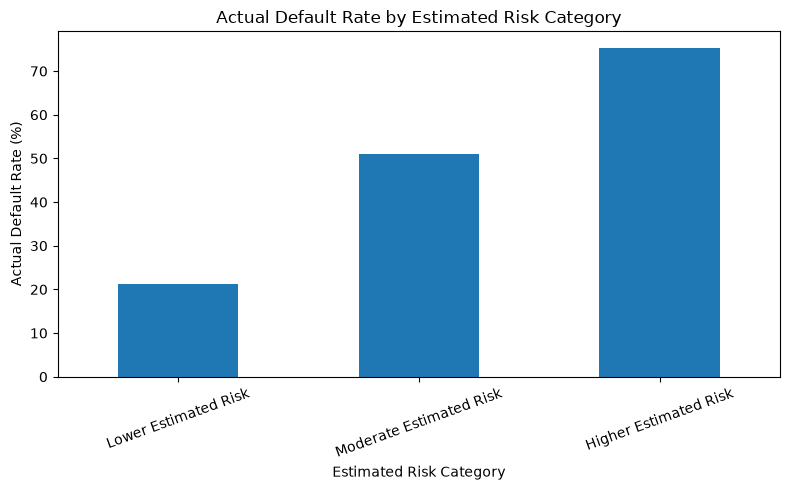

In [ ]:
# Plot actual default rate by estimated risk category
risk_category_results[
    "Actual_Default_Rate"
].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Actual Default Rate by Estimated Risk Category")
plt.xlabel("Estimated Risk Category")
plt.ylabel("Actual Default Rate (%)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Recommendation Interpretation

The risk-category analysis shows how the model could support a tiered review process.

Applications placed in the higher estimated risk category may receive more detailed review, while lower estimated risk applications may move through a more efficient process.

These categories are illustrative. A real lender should select thresholds using financial cost analysis, regulatory requirements, fairness testing, and business policy.

## 23. Limitations

This project has several limitations that should be considered when interpreting the results.

1. The models are based on historical loan data, so their performance may change when applied to future applicants.

2. Some variables contained missing or inconsistent values and required cleaning or imputation.

3. The inquiries dataset did not include a common application identifier or final loan outcome. Therefore, it could not be directly merged with the applications dataset at the individual-record level.

4. The target variable identifies whether a loan was charged off, but it does not measure the timing, severity, or financial amount of the default.

5. The dataset does not include wider economic conditions such as unemployment, inflation, or changing market interest rates.

6. Hyperparameter tuning tested a limited number of parameter combinations because a complete search would require substantially more computing time.

7. Feature importance shows predictive contribution, but it does not prove that a variable causes default.

8. Model performance was evaluated using one held-out test dataset. External validation using data from another period or organization would provide stronger evidence of generalizability.

9. The model may contain fairness concerns across regions or other applicant groups. These issues should be evaluated before real-world use.

10. Although obvious target-leakage variables were removed, a lender should confirm that every selected feature would be available at the time of the original credit decision.

11. The risk categories created in this project are illustrative and are not official lending thresholds.

12. The model should not be used as the only basis for approving or rejecting a loan application.

### Limitation Interpretation

These limitations do not make the analysis invalid. Instead, they explain the conditions under which the findings should be used.

The results are useful for understanding credit-risk patterns and comparing machine-learning models, but additional validation would be required before using the model in an operational lending environment.

## 24. Future Work

Several improvements could be explored in future analysis:

1. Test additional machine-learning models such as Gradient Boosting, XGBoost, or LightGBM.

2. Perform more extensive hyperparameter tuning using a larger search space.

3. Compare different classification thresholds using the estimated financial cost of false positives and false negatives.

4. Apply probability calibration so that predicted default probabilities are more reliable.

5. Add macroeconomic variables such as unemployment, inflation, and market interest rates.

6. Validate the model using applications from a later time period.

7. Conduct a detailed fairness analysis across relevant applicant groups.

8. Use advanced explanation methods such as SHAP values to explain individual predictions.

9. Collect a common application identifier so the inquiry dataset can be linked to final loan outcomes.

10. Monitor data drift and model-performance drift after deployment.

11. Test whether model performance changes across regions, loan purposes, or risk grades.

12. Develop a cost-sensitive model that gives greater importance to missed defaults.

### Future Work Interpretation

Cross-validation and Random Forest hyperparameter tuning were already completed in this project.

The items listed above represent additional improvements that could be explored later. They are not required to complete the current assignment.

## 25. Conclusion

This project completed a full data analytics and machine-learning workflow for predicting credit default.

The analysis included:

- Loading and inspecting the applications and inquiries datasets
- Identifying missing values and duplicate records
- Cleaning text-based numeric fields
- Creating the required `target_default` variable
- Exploring borrower, loan, and credit-risk patterns
- Creating visualizations to communicate important findings
- Engineering useful numeric and categorical features
- Removing variables that could create target leakage
- Building Logistic Regression and Random Forest models
- Evaluating models using Accuracy, Precision, Recall, F1-score, confusion matrices, and ROC-AUC
- Performing five-fold cross-validation
- Tuning the Random Forest model using randomized hyperparameter search
- Comparing the original and tuned models
- Developing business insights and practical recommendations

The final recommended model was selected using overall predictive performance, especially ROC-AUC, while also considering recall and classification errors.

Recall is important because a false negative represents an applicant predicted as non-default who later defaults. This type of error may expose a lender to financial loss.

The results show that historical borrower, loan, and credit-profile information can support credit-risk assessment. The model can help lenders identify higher-risk applications and prioritize cases for additional review.

However, the model should not replace professional judgment. Before real-world deployment, it would require external validation, fairness testing, threshold selection, regular monitoring, and continued improvement in data quality.

In [ ]:
print("=" * 60)
print("CREDIT DEFAULT RISK PROJECT COMPLETED")
print("=" * 60)

print("Final recommended model:", final_model_name)
print(
    "Final ROC-AUC:",
    round(final_model_scores[final_model_name], 4)
)

print(
    "Final false-negative rate:",
    round(final_false_negative_rate, 4)
)

print(
    "Final false-positive rate:",
    round(final_false_positive_rate, 4)
)

print("=" * 60)

CREDIT DEFAULT RISK PROJECT COMPLETED
Final recommended model: Tuned Random Forest
Final ROC-AUC: 0.7251
Final false-negative rate: 0.3089
Final false-positive rate: 0.3591


The Tuned Random Forest was selected as the final recommended model. It achieved an accuracy of 66.60%, precision of 65.81%, recall of 69.11%, F1-score of 67.42%, and ROC-AUC of 72.51% on the test dataset. It slightly outperformed the original Random Forest and Logistic Regression models, although the improvement from tuning was modest.